In [1]:
! mkdir -p ~/work/human_segmentation/models
! mkdir -p ~/work/human_segmentation/images

In [2]:
! pip install opencv-python pixellib

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.8/73.8 MB 39.7 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 49.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 948.0/948.0 kB 28.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 28.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 58.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 50.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 MB 38.6 MB/s eta 0:00:0000:0100:01
  DEPRECATION: Building 'fvcore' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` opt

In [3]:
# cv2: OpenCV 라이브러리로, 실시간 컴퓨터 비전을 목적으로 한 프로그래밍 라이브러리
# numpy(NumPy): 행렬이나 대규모 다차원 배열을 쉽게 처리할 수 있도록 지원하는 라이브러리. 데이터 구조 외에도 수치 계산을 위해 효율적으로 구현된 기능을 제공
# torch: PyTorch. 딥러닝 및 텐서 연산을 위한 라이브러리. 인공지능 모델을 만들거나 불러와 추론하는 도구
# torchvision: 이미지 변환 및 전처리를 위한 torchvision의 transform 모듈
# deeplabv3_resnet101: 사전 학습된 DeepLabV3 모델. 이미지를 분류하도록 학습된 모델
# matplotlib: 파이썬 프로그래밍 언어 및 수학적 확장 NumPy 라이브러리를 활용한 플로팅 라이브러리로, 데이터 시각화 도구

import cv2
import os
import numpy as np
import torch
import torchvision.transforms as T
from torchvision.models.segmentation import deeplabv3_resnet101
import matplotlib.pyplot as plt

# 1. 인물 사진에서 배경 블러 처리하기

### 1-1. 이미지 파일 준비

이미지 크기: (4220, 3376, 3)


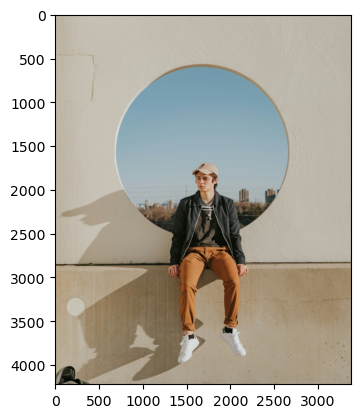

In [4]:
# 준비한 이미지 파일의 경로를 이용하여, 이미지 파일을 읽음

img_path = "Portrait.jpg"   # 업로드한 파일명으로 변경
img_orig = cv2.imread(img_path)

print(f"이미지 크기: {img_orig.shape}")

# cv2.cvtColor(입력 이미지, 색상 변환 코드): 입력 이미지의 색상 채널을 변경
# cv2.COLOR_BGR2RGB: 이미지 색상 채널을 변경 (BGR 형식을 RGB 형식으로 변경)
# plt.imshow(): 저장된 데이터를 이미지의 형식으로 표시, 입력은 RGB(A) 데이터 혹은 2D 스칼라 데이터
# plt.show(): 현재 열려있는 모든 figure를 표시 (여기서 figure는 이미지, 그래프 등)
plt.imshow(cv2.cvtColor(img_orig, cv2.COLOR_BGR2RGB))
plt.show()

In [5]:
model = deeplabv3_resnet101(pretrained=True).eval()

/opt/conda/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DeepLabV3_ResNet101_Weights.COCO_WITH_VOC_LABELS_V1`. You can also use `weights=DeepLabV3_ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/deeplabv3_resnet101_coco-586e9e4e.pth" to /home/jovyan/.cache/torch/hub/checkpoints/deeplabv3_resnet101_coco-586e9e4e.pth


100%|██████████| 233M/233M [00:02<00:00, 100MB/s]  


In [6]:
transform = T.Compose([
    T.ToPILImage(),        # NumPy 배열 -> PIL Image
    T.Resize((520, 520)),  # 모델 입력 크기 (고정)
    T.ToTensor(),          # PIL Image -> torch.Tensor
])

input_tensor = transform(cv2.cvtColor(img_orig, cv2.COLOR_BGR2RGB)).unsqueeze(0)  # (B,C,H,W)

### 1-3. Semantic Segmentation

In [7]:
# 평가 모드
with torch.no_grad():
    output = model(input_tensor)["out"][0]                        # 모델 예측 결과
    output_predictions = output.argmax(0).byte().cpu().numpy()    # 픽셀별 클래스 선택

# 원본 크기로 Resize
# 클래스 값 보존
output_predictions_resized = cv2.resize(output_predictions, (img_orig.shape[1], img_orig.shape[0]), interpolation=cv2.INTER_NEAREST)

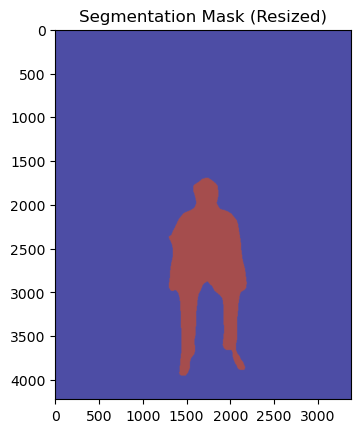

In [8]:
plt.imshow(output_predictions_resized, cmap="jet", alpha=0.7)
plt.title("Segmentation Mask (Resized)")
plt.show()

In [9]:
# pascalvoc 데이터의 라벨종류
LABEL_NAMES = [
    'background', 'aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus',
    'car', 'cat', 'chair', 'cow', 'diningtable', 'dog', 'horse', 'motorbike',
    'person', 'pottedplant', 'sheep', 'sofa', 'train', 'tv'
]
len(LABEL_NAMES)


# 예측된 클래스 종류 확인하기
unique_classes = np.unique(output_predictions_resized)

for class_id in unique_classes:
    print(LABEL_NAMES[class_id])

background
person


In [10]:
# Pascal VOC에서 사용하는 공식 컬러맵(Color Map)을 생성하는 코드
# 클래스 번호를 서로 구별되는 RGB 색상으로 변환

colormap = np.zeros((256, 3), dtype=int)
ind = np.arange(256, dtype=int)

for shift in reversed(range(8)):
    for channel in range(3):
        colormap[:, channel] |= ((ind >> channel) & 1) << shift
    ind >>= 3

colormap[:20]  # 생성한 20개의 컬러맵 출력

array([[  0,   0,   0],
       [128,   0,   0],
       [  0, 128,   0],
       [128, 128,   0],
       [  0,   0, 128],
       [128,   0, 128],
       [  0, 128, 128],
       [128, 128, 128],
       [ 64,   0,   0],
       [192,   0,   0],
       [ 64, 128,   0],
       [192, 128,   0],
       [ 64,   0, 128],
       [192,   0, 128],
       [ 64, 128, 128],
       [192, 128, 128],
       [  0,  64,   0],
       [128,  64,   0],
       [  0, 192,   0],
       [128, 192,   0]])

### 1-4. person 클래스는 흰색, background 클래스는 검정색으로 나타내기

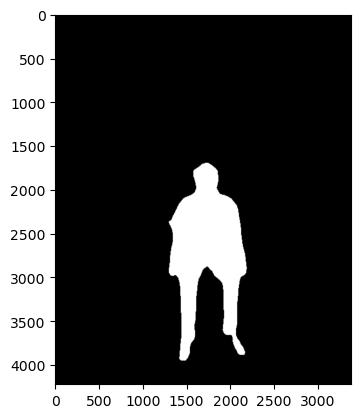

In [11]:
seg_map = (output_predictions_resized == 15)    # 픽셀 별로 예측된 class가 사람이라면 1(True), 다르다면 0(False)
img_mask = seg_map.astype(np.uint8) * 255       # 255 값으로 변환

plt.imshow(img_mask, cmap='gray')  # 흑백으로 표시
plt.show()

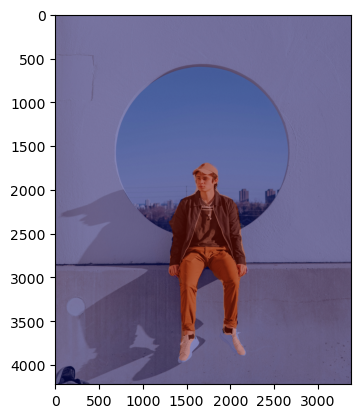

In [12]:
color_mask = cv2.applyColorMap(img_mask, cv2.COLORMAP_JET)

img_show = cv2.addWeighted(img_orig, 0.6, color_mask, 0.4, 0.0)    # 6:4 비율로 이미지 섞음

plt.imshow(cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB))
plt.show()

### 1-5. 전체 이미지 블러 처리
- blurring kernel 사이즈를 크게 할 수록 블러 정도가 커짐

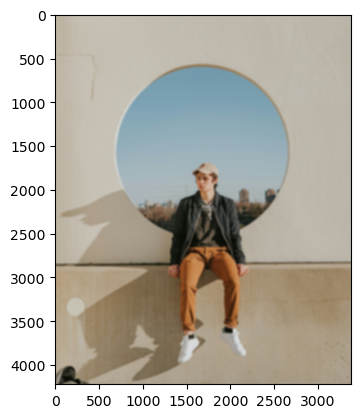

In [13]:
# (30,30): blurring kernel size
img_orig_blur = cv2.blur(img_orig, (30, 30))

plt.imshow(cv2.cvtColor(img_orig_blur, cv2.COLOR_BGR2RGB))
plt.show()

### 1-5. bitwise_not와 bitwise_and를 이용하여 배경만 추출

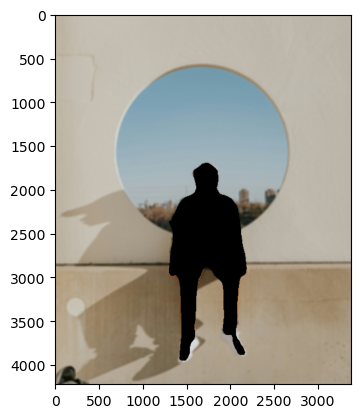

In [16]:
img_mask_color = cv2.cvtColor(img_mask, cv2.COLOR_GRAY2BGR)

# cv2.bitwise_not(): 이미지 반전
# 0 -> 255(배경) / 255 -> 0(사람)
img_bg_mask = cv2.bitwise_not(img_mask_color)

# cv2.bitwise_and(): 픽셀 값들의 AND 연산을 통해 배경만 추출
# 어떤 값이든 0과 AND 연산 수행시 0이 됨
img_bg_blur = cv2.bitwise_and(img_orig_blur, img_bg_mask)
plt.imshow(cv2.cvtColor(img_bg_blur, cv2.COLOR_BGR2RGB))
plt.show()

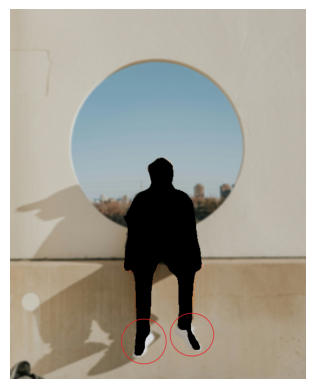

In [17]:
import matplotlib.image as mpimg

img = mpimg.imread("img_bg_blur_result.jpg")

plt.imshow(img)
plt.axis("off")
plt.show()

- 신발 부분이 덜 선택 된 것을 확인 할 수 있음

### 1-6. 원본 이미지 + 블러 처리된 배경 이미지

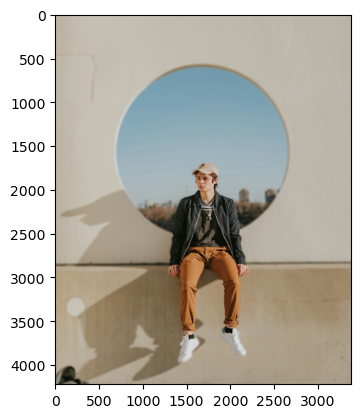

In [25]:
# np.where(조건, 참일때, 거짓일때)
# 세그멘테이션 마스크가 255인 부분만 원본 이미지 값을 가지고 오고
# 아닌 영역은 블러된 이미지 값을 사용
img_concat = np.where(img_mask_color==255, img_orig, img_bg_blur)

plt.imshow(cv2.cvtColor(img_concat, cv2.COLOR_BGR2RGB))
plt.show()

# 2. 동물 사진에서 배경 블러 처리하기

이미지 크기: (663, 928, 3)


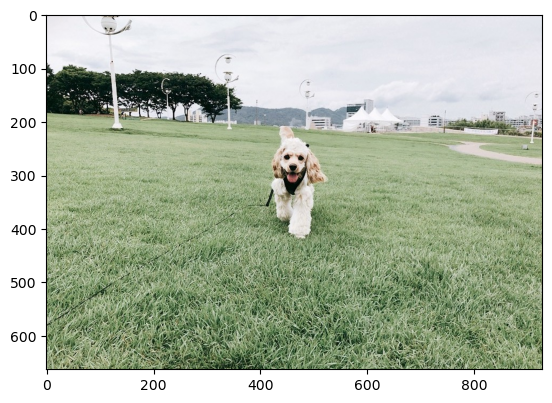

In [66]:
img_path = "Dog.JPG"
DogImg_orig = cv2.imread(img_path)

print(f"이미지 크기: {DogImg_orig.shape}")

plt.imshow(cv2.cvtColor(DogImg_orig, cv2.COLOR_BGR2RGB))
plt.show()

In [67]:
transform = T.Compose([
    T.ToPILImage(),        # NumPy 배열 -> PIL Image
    T.Resize((520, 520)),  # 모델 입력 크기 (고정)
    T.ToTensor(),          # PIL Image -> torch.Tensor
])

input_tensor = transform(cv2.cvtColor(DogImg_orig, cv2.COLOR_BGR2RGB)).unsqueeze(0)  # (B,C,H,W)

In [68]:
# 평가 모드
with torch.no_grad():
    output = model(input_tensor)["out"][0]                        # 모델 예측 결과
    output_predictions = output.argmax(0).byte().cpu().numpy()    # 픽셀별 클래스 선택

# 원본 크기로 Resize
# 클래스 값 보존
output_predictions_resized = cv2.resize(output_predictions, (DogImg_orig.shape[1], DogImg_orig.shape[0]), interpolation=cv2.INTER_NEAREST)

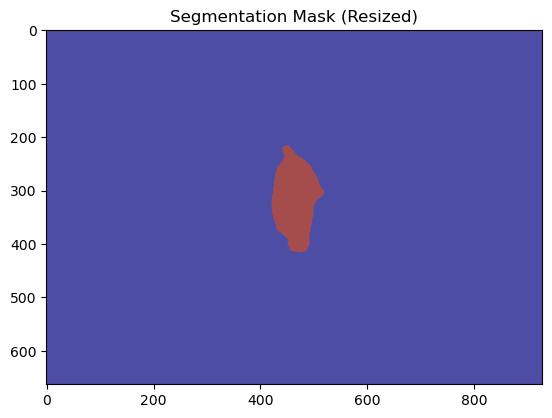

In [69]:
plt.imshow(output_predictions_resized, cmap="jet", alpha=0.7)
plt.title("Segmentation Mask (Resized)")
plt.show()

In [70]:
# 예측된 클래스 종류 확인하기
unique_classes = np.unique(output_predictions_resized)

for class_id in unique_classes:
    print(LABEL_NAMES[class_id])

background
dog


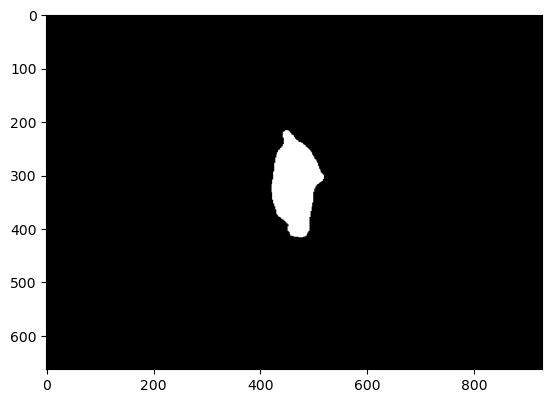

In [71]:
seg_map = (output_predictions_resized == 12)    # 픽셀 별로 예측된 class가 개라면 1(True), 다르다면 0(False)
img_mask = seg_map.astype(np.uint8) * 255       # 255 값으로 변환

plt.imshow(img_mask, cmap='gray')  # 흑백으로 표시
plt.show()

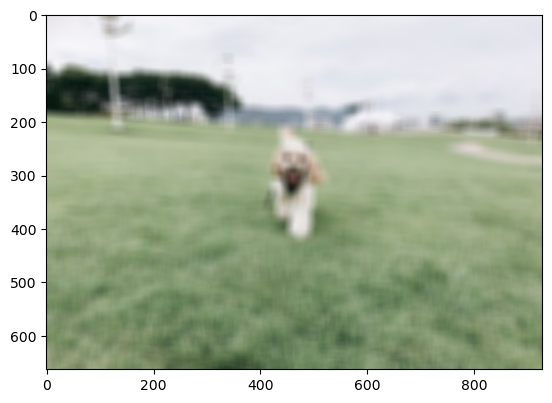

In [72]:
# (20,20): blurring kernel size
DogImg_orig_blur = cv2.blur(DogImg_orig, (20, 20))

plt.imshow(cv2.cvtColor(DogImg_orig_blur, cv2.COLOR_BGR2RGB))
plt.show()

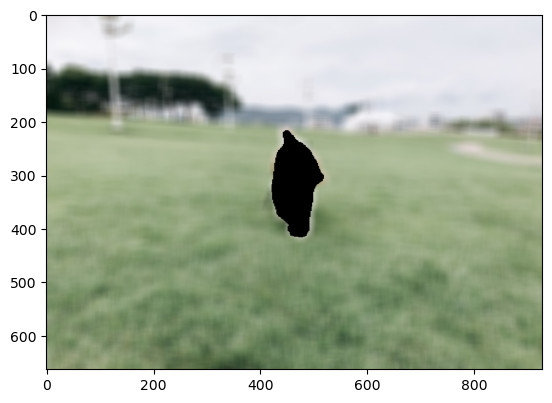

In [73]:
img_mask_color = cv2.cvtColor(img_mask, cv2.COLOR_GRAY2BGR)

# cv2.bitwise_not(): 이미지 반전
# 0 -> 255(배경) / 255 -> 0(사람)
img_bg_mask = cv2.bitwise_not(img_mask_color)

# cv2.bitwise_and(): 픽셀 값들의 AND 연산을 통해 배경만 추출
# 어떤 값이든 0과 AND 연산 수행시 0이 됨
img_bg_blur = cv2.bitwise_and(DogImg_orig_blur, img_bg_mask)
plt.imshow(cv2.cvtColor(img_bg_blur, cv2.COLOR_BGR2RGB))
plt.show()

- 귀랑 꼬리 부분이 덜 포함 된 것을 확인 할 수 있음

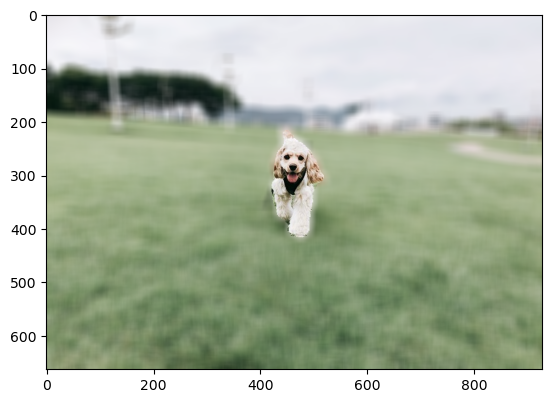

In [74]:
# np.where(조건, 참일때, 거짓일때)
# 세그멘테이션 마스크가 255인 부분만 원본 이미지 값을 가지고 오고
# 아닌 영역은 블러된 이미지 값을 사용
img_concat = np.where(img_mask_color==255, DogImg_orig, img_bg_blur)

plt.imshow(cv2.cvtColor(img_concat, cv2.COLOR_BGR2RGB))
plt.show()

# 3. 배경전환 크로마키사진

이미지 크기: (359, 640, 3)
이미지 크기: (663, 928, 3)


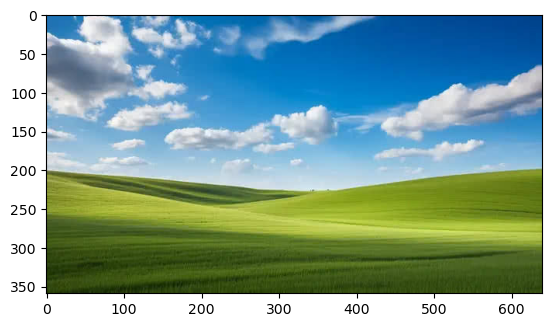

In [51]:
img_path = "background.jpeg"
BackImg_orig = cv2.imread(img_path)

print(f"이미지 크기: {BackImg_orig.shape}")
print(f"이미지 크기: {DogImg_orig.shape}")

plt.imshow(cv2.cvtColor(BackImg_orig, cv2.COLOR_BGR2RGB))
plt.show()

In [53]:
# 배경 이미지를 강아지 이미지 크기로 변경
BackImg_resize = cv2.resize(BackImg_orig, (DogImg_orig.shape[1], DogImg_orig.shape[0]))

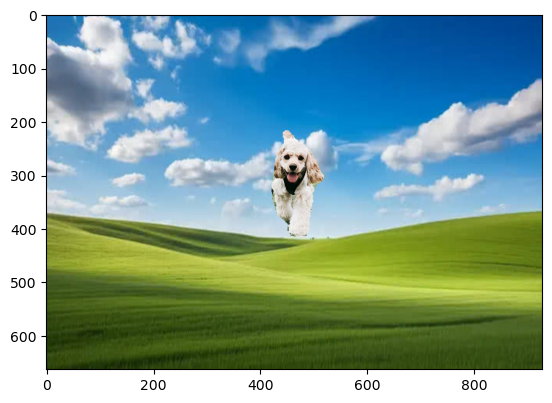

In [55]:
# np.where(조건, 참일때, 거짓일때)
# 세그멘테이션 마스크가 255인 부분만 원본 이미지 값을 가지고 오고
# 아닌 영역은 블러된 이미지 값을 사용
img_concat = np.where(img_mask_color==255, DogImg_orig, BackImg_resize)

plt.imshow(cv2.cvtColor(img_concat, cv2.COLOR_BGR2RGB))
plt.show()

# 4. 더 좋은 성능을 내기 위한 방법
1. OpenCV의 Erosion, Dilation, Opening, Closing 연산을 이용하여 마스크를 보정
   - 객체 내부에 생긴 빈 영역을 제거할 수 있음
   - 노이즈를 줄여 더욱 깔끔한 마스크를 얻을 수 있음
2. 더 높은 해상도의 입력 이미지 사용
   - 작은 객체나 얇은 경계 정보가 손실 되는 것을 방지함
3. Mask2Former, SegFormer, SAM(Segment Anything Model)와 같은 더 좋은 성능의 모델 사용

In [78]:
img_path = "Dog.JPG"
DogImg_orig = cv2.imread(img_path)

transform = T.Compose([
    T.ToPILImage(),        # NumPy 배열 -> PIL Image
    T.Resize((520, 520)),  # 모델 입력 크기 (고정)
    T.ToTensor(),          # PIL Image -> torch.Tensor
])

input_tensor = transform(cv2.cvtColor(DogImg_orig, cv2.COLOR_BGR2RGB)).unsqueeze(0)  # (B,C,H,W)

# 평가 모드
with torch.no_grad():
    output = model(input_tensor)["out"][0]                        # 모델 예측 결과
    output_predictions = output.argmax(0).byte().cpu().numpy()    # 픽셀별 클래스 선택

# 원본 크기로 Resize
# 클래스 값 보존
output_predictions_resized = cv2.resize(output_predictions, (DogImg_orig.shape[1], DogImg_orig.shape[0]), interpolation=cv2.INTER_NEAREST)

# 강아지 클래스 마스크 생성
seg_map = (output_predictions_resized == 12)

# Boolean → 0,255 마스크
img_mask = seg_map.astype(np.uint8) * 255

## Morphology 적용

In [79]:
# Morphology 적용 (작은 구멍 메우기)
kernel = np.ones((5,5), np.uint8)
img_mask = cv2.morphologyEx(img_mask, cv2.MORPH_CLOSE, kernel)

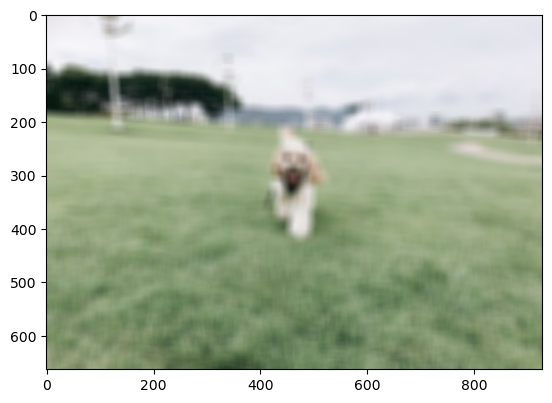

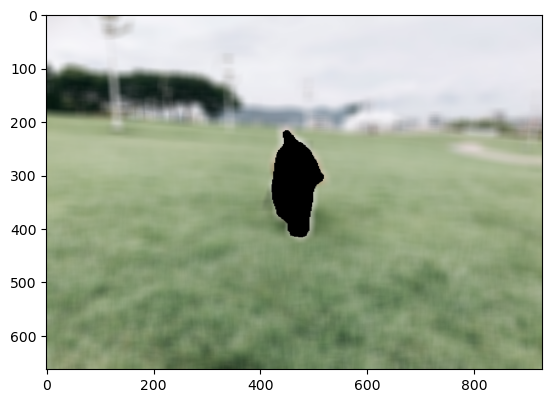

In [80]:
# (20,20): blurring kernel size
DogImg_orig_blur = cv2.blur(DogImg_orig, (20, 20))

plt.imshow(cv2.cvtColor(DogImg_orig_blur, cv2.COLOR_BGR2RGB))
plt.show()

img_mask_color = cv2.cvtColor(img_mask, cv2.COLOR_GRAY2BGR)

# cv2.bitwise_not(): 이미지 반전
# 0 -> 255(배경) / 255 -> 0(사람)
img_bg_mask = cv2.bitwise_not(img_mask_color)

# cv2.bitwise_and(): 픽셀 값들의 AND 연산을 통해 배경만 추출
# 어떤 값이든 0과 AND 연산 수행시 0이 됨
img_bg_blur = cv2.bitwise_and(DogImg_orig_blur, img_bg_mask)
plt.imshow(cv2.cvtColor(img_bg_blur, cv2.COLOR_BGR2RGB))
plt.show()

- Morphology는 후처리 기법으로, 마스크를 좀 더 부드럽게 연결 시켜줄 뿐 모델이 잘못 예측한 부분까지 개선 하지는 못함
- 다른 모델을 사용하는 것이 성능 향상에 더 큰 기여를 할 것으로 예상됨